# Transfomers -> signal processing (demand)

In [1]:
# DataFrame
import pandas as pd
import numpy as np
import random
from datetime import date
import matplotlib.dates as mdates
import matplotlib

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# Visualization
import matplotlib.pyplot as plt
# LSTM in PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import optuna
# Metric 
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [2]:
demand_data = pd.read_csv("PRICE_AND_DEMAND_202501_NSW1.csv")

In [3]:
demand_data

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2025/01/01 00:05:00,7251.07,138.03,TRADE
1,NSW1,2025/01/01 00:10:00,7297.85,134.42,TRADE
2,NSW1,2025/01/01 00:15:00,7274.39,135.89,TRADE
3,NSW1,2025/01/01 00:20:00,7173.05,120.31,TRADE
4,NSW1,2025/01/01 00:25:00,7140.49,119.89,TRADE
...,...,...,...,...,...
8923,NSW1,2025/01/31 23:40:00,7263.08,76.00,TRADE
8924,NSW1,2025/01/31 23:45:00,7288.16,75.90,TRADE
8925,NSW1,2025/01/31 23:50:00,7216.32,75.90,TRADE
8926,NSW1,2025/01/31 23:55:00,7219.35,75.90,TRADE


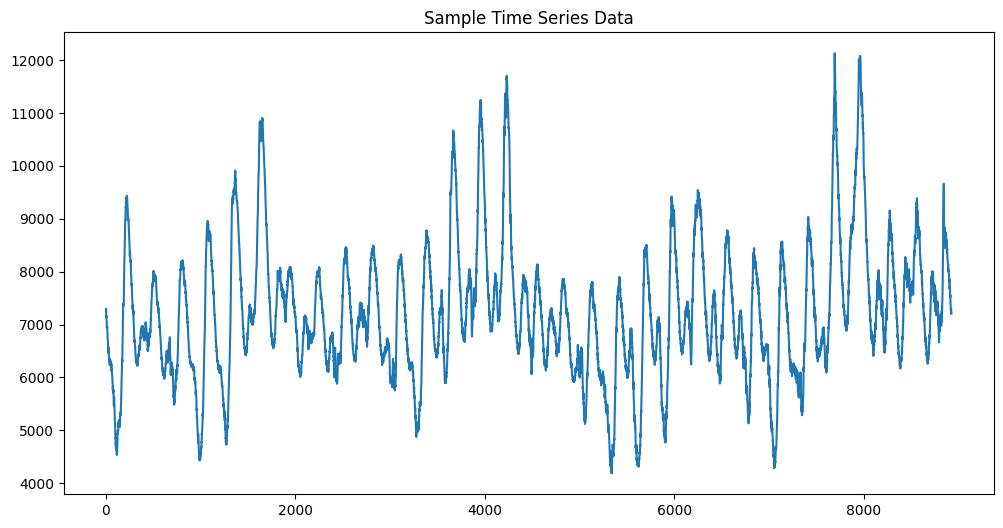

In [4]:
# Plot the data to visualize it
plt.figure(figsize=(12, 6))
plt.plot(demand_data["TOTALDEMAND"])
plt.title("Sample Time Series Data")
plt.show()

In [5]:
def create_dataset(data, window_size, horizon=1):
    """
    Creates a sliding window dataset for time series forecasting.
    
    Args:
        data (np.array): The input time series data.
        window_size (int): The number of past timesteps to use as input.
        horizon (int): The number of future timesteps to predict.
        
    Returns:
        tuple: A tuple of (inputs, outputs) where inputs are the
               sequences and outputs are the corresponding labels.
    """
    inputs = []
    outputs = []
    
    # Iterate through the data to create the sliding windows
    for i in range(len(data) - window_size - horizon + 1):
        
        # Define the input sequence (the window)
        input_sequence = data[i : i + window_size]
        
        # Define the output (the horizon)
        output_value = data[i + window_size : i + window_size + horizon]
        
        inputs.append(input_sequence)
        outputs.append(output_value)
    
    return np.array(inputs), np.array(outputs)

In [6]:
# Define the parameters for your problem
WINDOW_SIZE = 50
HORIZON = 1

# Create the dataset
X, y = create_dataset(np.array(demand_data["TOTALDEMAND"]), window_size=WINDOW_SIZE, horizon=HORIZON)

# Print the shapes to see the result
print(f"Shape of inputs (X): {X.shape}")
print(f"Shape of outputs (y): {y.shape}")

# Print the first few examples to inspect them
print("\nFirst 5 input sequences (X):")
print(X[:5])
print("\nFirst 5 output values (y):")
print(y[:5])

Shape of inputs (X): (8878, 50)
Shape of outputs (y): (8878, 1)

First 5 input sequences (X):
[[7251.07 7297.85 7274.39 7173.05 7140.49 7162.36 7078.85 7051.56 7029.33
  6941.93 6962.78 6970.56 6949.87 6960.56 6899.02 6807.22 6794.64 6745.76
  6720.28 6712.49 6690.95 6652.11 6571.64 6590.09 6536.66 6568.22 6488.58
  6459.04 6508.42 6439.9  6407.11 6403.53 6382.74 6368.9  6350.32 6297.55
  6356.19 6297.22 6348.26 6275.24 6240.06 6266.13 6229.95 6315.79 6278.14
  6280.26 6242.9  6229.77 6268.1  6310.74]
 [7297.85 7274.39 7173.05 7140.49 7162.36 7078.85 7051.56 7029.33 6941.93
  6962.78 6970.56 6949.87 6960.56 6899.02 6807.22 6794.64 6745.76 6720.28
  6712.49 6690.95 6652.11 6571.64 6590.09 6536.66 6568.22 6488.58 6459.04
  6508.42 6439.9  6407.11 6403.53 6382.74 6368.9  6350.32 6297.55 6356.19
  6297.22 6348.26 6275.24 6240.06 6266.13 6229.95 6315.79 6278.14 6280.26
  6242.9  6229.77 6268.1  6310.74 6302.06]
 [7274.39 7173.05 7140.49 7162.36 7078.85 7051.56 7029.33 6941.93 6962.78
  6970

Reshaping for a Transformer

The transformer encoder expects a 3D input tensor with the shape (batch_size, sequence_length, num_features). In your case, num_features is 1. We need to reshape the X and y tensors to match this.

In [7]:
# Reshape X to be (num_samples, window_size, 1)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Reshape y to be (num_samples, 1) - it's already in this shape, but
# a quick check is good practice. Let's make sure it's a 2D array.
y = y.reshape(y.shape[0], HORIZON)

print("\nShapes after reshaping for the transformer:")
print(f"Reshaped X shape: {X.shape}")
print(f"Reshaped y shape: {y.shape}")


Shapes after reshaping for the transformer:
Reshaped X shape: (8878, 50, 1)
Reshaped y shape: (8878, 1)


Train/Test Split and Normalization

Before training, it's essential to split your data and normalize it. For time series, you must not shuffle the data, as that would destroy the temporal order. You should split it chronologically.

In [8]:
# Define the split ratio
train_size = int(len(X) * 0.8)

# Split the data chronologically
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

print("\nShapes of training and testing sets:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Shapes of training and testing sets:
X_train shape: (7102, 50, 1), y_train shape: (7102, 1)
X_test shape: (1776, 50, 1), y_test shape: (1776, 1)


### Transformer Architecture in PyTorch for Time Series Forecasting

We will use PyTorch's built-in `TransformerEncoderLayer` and `TransformerEncoder` classes to simplify the implementation. The key additions are the `PositionalEncoding` layer and the final prediction head.

In [9]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Scale X data
X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
X_test_reshaped = X_test.reshape(-1, X_test.shape[2])
X_train_scaled = scaler_X.fit_transform(X_train_reshaped).reshape(X_train.shape)
X_test_scaled = scaler_X.transform(X_test_reshaped).reshape(X_test.shape)

# Scale y data
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Convert to PyTorch tensors and move to device
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

### 3\. Positional Encoding

This is a critical component for transformers to understand the sequence order. We use a standard sine and cosine function-based approach.

In [11]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape [seq_len, batch_size, embedding_dim]
        """
        x = x + self.pe[:x.size(0), :]
        return x

### 4\. The Transformer Model

This class combines the positional encoding, the PyTorch transformer encoder, and a simple linear layer for the final prediction.

In [12]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size, d_model, nhead, num_encoder_layers, dim_feedforward, output_size, dropout=0.1):
        super(TimeSeriesTransformer, self).__init__()
        
        self.d_model = d_model
        
        # Linear layer to project the input features to the d_model size
        self.input_projection = nn.Linear(input_size, d_model)
        
        # Positional Encoding layer
        self.positional_encoding = PositionalEncoding(d_model)
        
        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=False  # The first dimension is sequence length
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_encoder_layers)
        
        # Final output layer to predict the next timestep
        self.linear_head = nn.Linear(d_model, output_size)

    def forward(self, src):
        # src shape: [batch_size, sequence_length, num_features]
        
        # Reshape to [sequence_length, batch_size, num_features] for PyTorch transformer
        src = src.permute(1, 0, 2)
        
        # Project input features to d_model
        src = self.input_projection(src)
        
        # Add positional encoding
        src = self.positional_encoding(src)
        
        # Pass through the transformer encoder
        output = self.transformer_encoder(src)
        
        # We take the output of the last timestep (or a pooled representation) for forecasting.
        # Let's take the output of the last timestep.
        output = output[-1, :, :]
        
        # Pass through the final linear layer
        output = self.linear_head(output)
        
        return output

### 5\. Training Loop

Now we can instantiate the model, define the optimizer and loss function, and run the training process.

In [14]:
# Model parameters
INPUT_SIZE = 1        # Number of features
D_MODEL = 128          # The embedding dimension
NHEAD = 4             # Number of attention heads
NUM_ENCODER_LAYERS = 2 # Number of encoder layers
DIM_FEEDFORWARD = 128 # The dimension of the feedforward network model
OUTPUT_SIZE = 1       # Number of values to predict
BATCH_SIZE = 64
EPOCHS = 50

# Create DataLoader for batch processing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Instantiate the model
model = TimeSeriesTransformer(
    input_size=INPUT_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    output_size=HORIZON
).to(device)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        
        predictions = model(batch_X)
        
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss / len(train_loader):.4f}')

print("Training finished.")

C:\Users\decis\anaconda3\envs\kaveh\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [10/50], Loss: 0.0038
Epoch [20/50], Loss: 0.0011
Epoch [30/50], Loss: 0.0004
Epoch [40/50], Loss: 0.0005
Epoch [50/50], Loss: 0.0004
Training finished.


### 6\. Evaluation and Visualization

Finally, let's use the trained model to make predictions on the test set and visualize the results.

In [15]:
model.eval()
with torch.no_grad():
    # Make predictions on the test set
    # test_predictions_scaled will now have shape (num_test_samples, HORIZON)
    test_predictions_scaled = model(X_test_tensor).cpu().numpy()

# Inverse transform the predictions to the original scale
test_predictions = scaler_y.inverse_transform(test_predictions_scaled)

# Inverse transform the actual y_test_scaled to the original scale
y_test_original = scaler_y.inverse_transform(y_test_scaled)

print(f"Shape of inverse-transformed test predictions: {test_predictions.shape}")
print(f"Shape of inverse-transformed actual test values: {y_test_original.shape}")

Shape of inverse-transformed test predictions: (1776, 1)
Shape of inverse-transformed actual test values: (1776, 1)


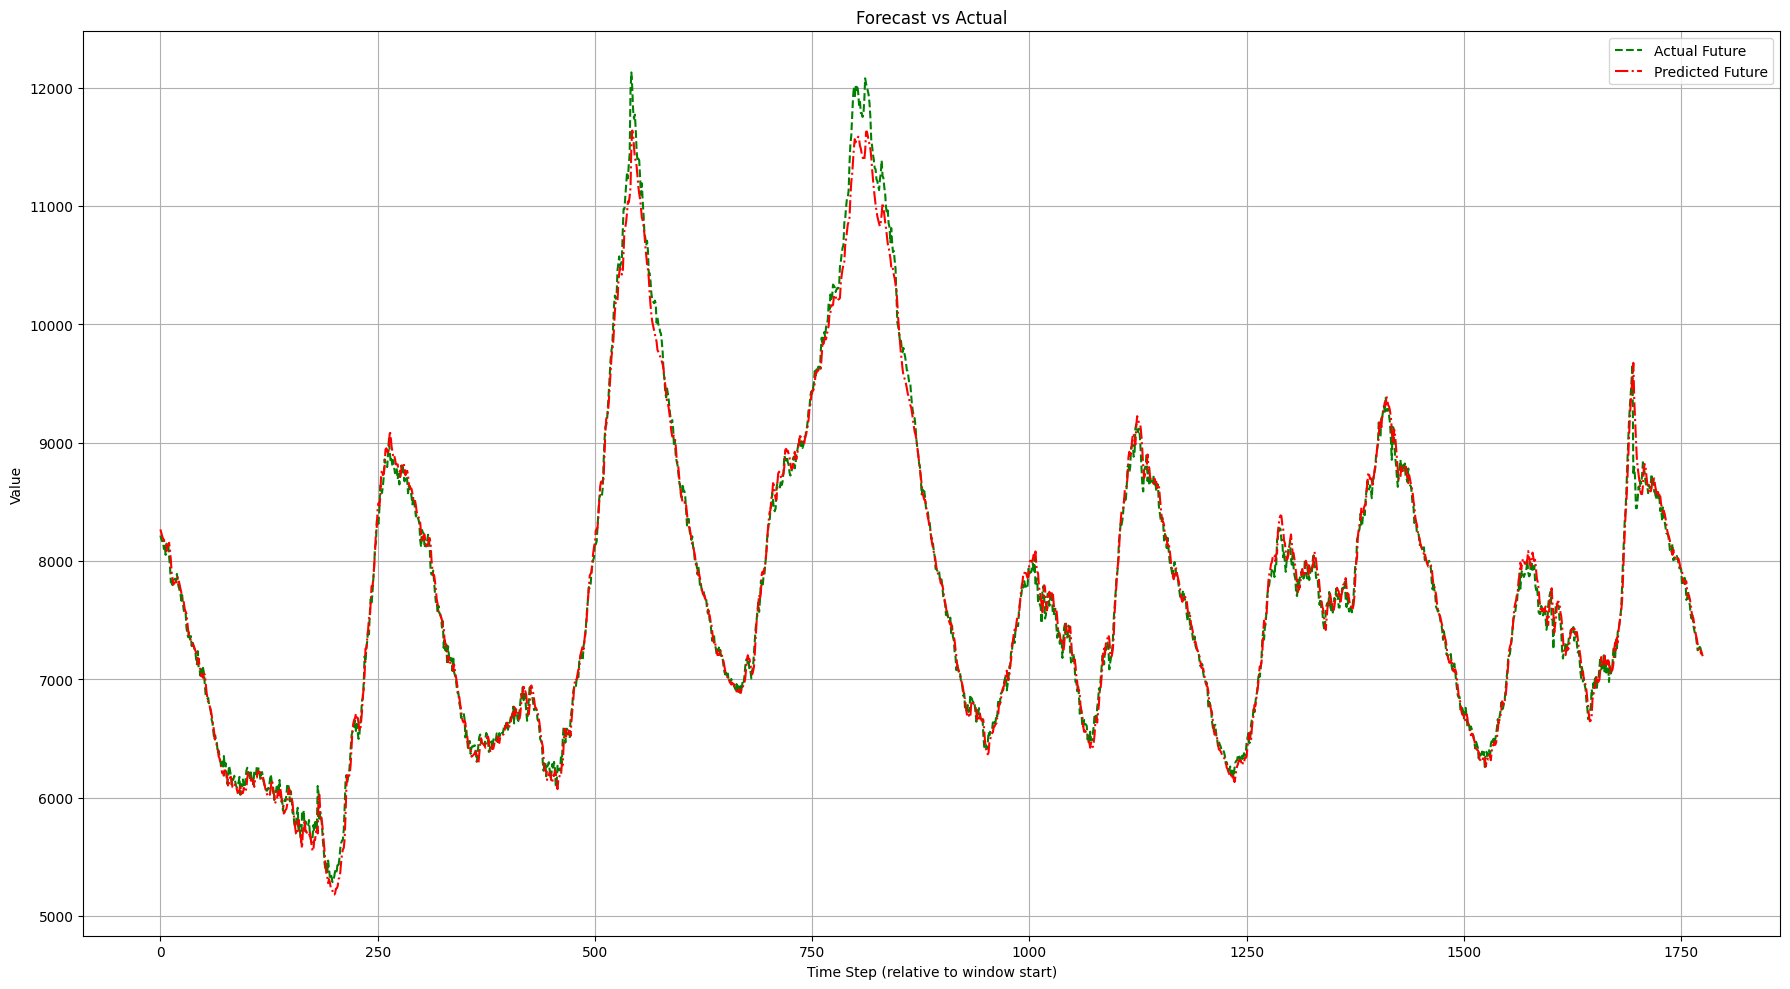

In [19]:
plt.figure(figsize=(18, 10))
# Plot the actual future values
plt.plot(np.arange(len(y_test_original)), y_test_original, label='Actual Future', color='green', linestyle='--')

# Plot the predicted future values
plt.plot(np.arange(len(y_test_original)), test_predictions, label='Predicted Future', color='red', linestyle='-.')

plt.title(f'Forecast vs Actual')
plt.xlabel('Time Step (relative to window start)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
# Calculate Mean Squared Error
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test_original, test_predictions)
print(f"Mean Squared Error on Test Set: {mse:.4f}")

# Calculate R-squared
r2 = r2_score(y_test_original, test_predictions)
print(f"R-squared: {r2}")

Mean Squared Error on Test Set: 13512.0947
R-squared: 0.9923729527611179


# predict into the future

In [45]:
demand_data

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2025/01/01 00:05:00,7251.07,138.03,TRADE
1,NSW1,2025/01/01 00:10:00,7297.85,134.42,TRADE
2,NSW1,2025/01/01 00:15:00,7274.39,135.89,TRADE
3,NSW1,2025/01/01 00:20:00,7173.05,120.31,TRADE
4,NSW1,2025/01/01 00:25:00,7140.49,119.89,TRADE
...,...,...,...,...,...
8923,NSW1,2025/01/31 23:40:00,7263.08,76.00,TRADE
8924,NSW1,2025/01/31 23:45:00,7288.16,75.90,TRADE
8925,NSW1,2025/01/31 23:50:00,7216.32,75.90,TRADE
8926,NSW1,2025/01/31 23:55:00,7219.35,75.90,TRADE


In [46]:
test_data = pd.read_csv("PRICE_AND_DEMAND_202502_NSW1.csv")

In [47]:
test_data

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2025/02/01 00:05:00,7133.42,76.00,TRADE
1,NSW1,2025/02/01 00:10:00,7138.73,75.90,TRADE
2,NSW1,2025/02/01 00:15:00,7026.02,75.90,TRADE
3,NSW1,2025/02/01 00:20:00,6985.95,76.00,TRADE
4,NSW1,2025/02/01 00:25:00,6926.08,75.90,TRADE
...,...,...,...,...,...
8059,NSW1,2025/02/28 23:40:00,8465.09,139.23,TRADE
8060,NSW1,2025/02/28 23:45:00,8278.52,116.84,TRADE
8061,NSW1,2025/02/28 23:50:00,8321.78,116.22,TRADE
8062,NSW1,2025/02/28 23:55:00,8214.32,114.85,TRADE


---

## **Why Long-Horizon Auto-Regressive Forecasting Degrades**

When you train your model to predict **only the next step** (1-step ahead), it learns patterns valid over short horizons.
But in iterative forecasting (feeding predictions back in), you introduce two compounding effects:

1. **Error Accumulation**

   * Each prediction is slightly off from the true value.
   * Feeding it back means the next prediction starts from a slightly wrong place.
   * Over 1000 steps, small biases snowball into large drifts.

2. **Distribution Shift**

   * During training, your model always saw “real” historical inputs.
   * During long-term prediction, it sees its **own imperfect outputs** instead — a distribution it wasn’t trained on.
   * This mismatch means the model can quickly start producing unrealistic sequences.

---

## **What Typically Happens in Practice**

* If the signal is **highly autocorrelated and low noise** (e.g., slowly changing temperature in a lab), your model may hold up for many steps before drifting.
* If the signal has **chaotic or high-frequency variations** (like energy demand spikes or financial prices), accuracy collapses very quickly — sometimes after just a few dozen steps.
* Forecasts often start **smooth and plausible** for the first part of the horizon but then converge toward unrealistic flatlines, exploding values, or oscillations.

---

## **Ways to Make Long-Horizon AR Forecasting More Reliable**

1. **Direct multi-step training**
   Train the model to predict multiple future steps at once (e.g., 10, 50, or 100 steps ahead) so it learns long-range dependencies.

2. **Scheduled sampling** (a.k.a. professor forcing)
   During training, sometimes feed the model’s own predictions back in so it learns to deal with its own imperfect inputs.

3. **Hybrid approach**
   Combine short-term AR predictions with a slower-moving trend or seasonal baseline model.

4. **Stateful or recurrent architectures**
   Models like LSTM/GRU/Transformer with context windows or learned hidden states often handle long-term structure better than a pure feed-forward AR approach.

---

**Bottom line:**
If you trained a 5-step lookback model for **1-step ahead only** and try to push it for 1000 steps autoregressively, expect severe drift unless your data is *exceptionally predictable*.
